<a href="https://colab.research.google.com/github/zain4cs/customer-churn-prediction-ml/blob/main/Telecom_Cutomer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print("Churn Customer")
print(df['Churn'].value_counts())

Churn Customer
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [7]:
print("Percantage!")
print(df['Churn'].value_counts(normalize=True)*100)

Percantage!
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Graph 1: Churn Count**

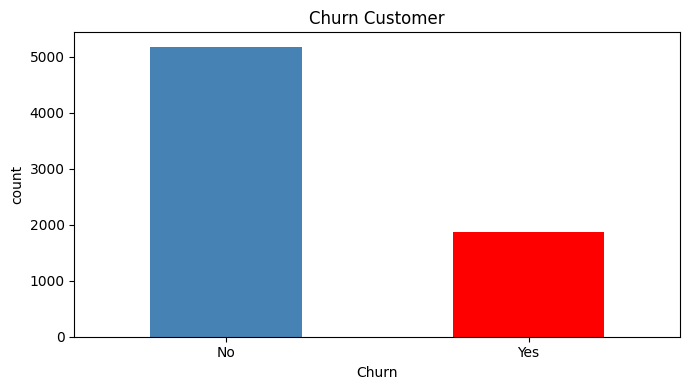

In [8]:
plt.figure(figsize=(7,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Churn Customer')
plt.xlabel('Churn')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
# plt.savefig('churn_graph.png', dpi=150)
plt.show()

**Graph 2: Contract Type vs Churn**

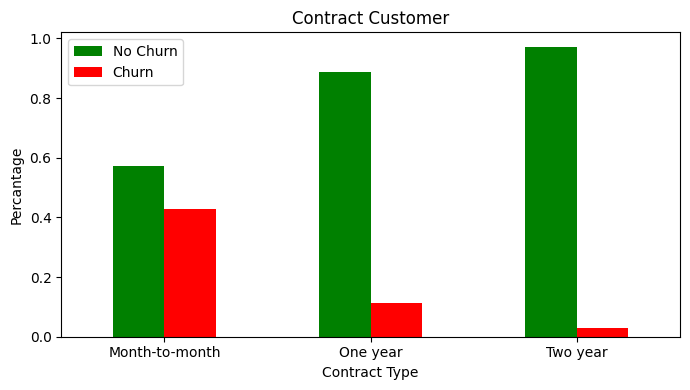

In [9]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
contract_churn.plot(kind='bar', color=['green', 'red'], figsize=(7, 4))
plt.title('Contract Customer')
plt.xticks(rotation=0)
plt.xlabel('Contract Type')
plt.ylabel('Percantage')
plt.legend(['No Churn', 'Churn'])
plt.tight_layout()
plt.show()


In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

**Graph 3: Monthly Charges vs Churn**

In [11]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


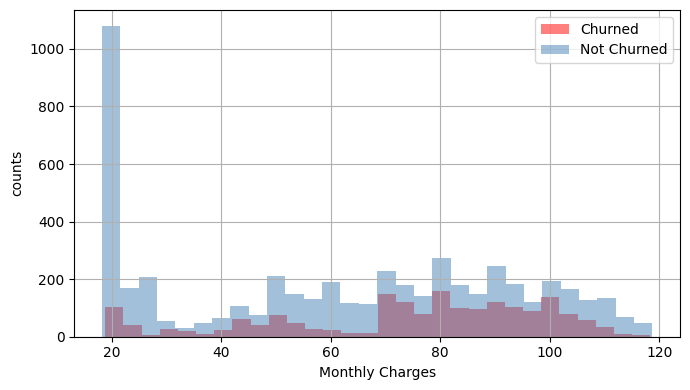

In [12]:
plt.figure(figsize=(7,4))
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(bins=30, alpha=0.5, color='red', label='Churned')
df[df['Churn'] == 'No']['MonthlyCharges'].hist(bins=30, alpha=0.5, color='steelblue', label='Not Churned')
plt.xlabel('Monthly Charges')
plt.ylabel('counts')
plt.legend()
plt.tight_layout()
plt.show()

**Graph 4: Tenure vs Churn**

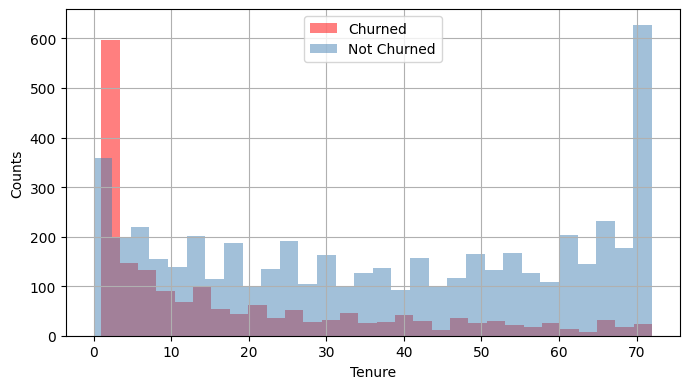

In [13]:
plt.figure(figsize=(7,4))
df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, alpha=0.5, color='red', label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=30, alpha=0.5, color='steelblue', label='Not Churned')
plt.xlabel('Tenure')
plt.ylabel('Counts')
plt.legend()
plt.tight_layout()
plt.show()

____________________

**DATA CLEANING**

In [14]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [15]:
print("Total dtype: ", df['TotalCharges'].dtype)
print("Missing Value: ", df['TotalCharges'].isnull().sum())

Total dtype:  float64
Missing Value:  11


In [16]:
df = df.dropna()
print("Shape after Dropping: ", df.shape)

Shape after Dropping:  (7032, 21)


Drop Useless Column

In [17]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
df = df.drop(columns=['customerID'])
print("Shape: ", df.shape)

Shape:  (7032, 20)


**Target Variable**

In [19]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [20]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [21]:
cat_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod'
]

for col in cat_cols:
  print(f"---" *15 )
  print(df[col].value_counts(normalize=True)*100)


---------------------------------------------
Partner
No     51.749147
Yes    48.250853
Name: proportion, dtype: float64
---------------------------------------------
Dependents
No     70.150739
Yes    29.849261
Name: proportion, dtype: float64
---------------------------------------------
PhoneService
Yes    90.32992
No      9.67008
Name: proportion, dtype: float64
---------------------------------------------
MultipleLines
No                  48.137088
Yes                 42.192833
No phone service     9.670080
Name: proportion, dtype: float64
---------------------------------------------
InternetService
Fiber optic    44.027304
DSL            34.357224
No             21.615472
Name: proportion, dtype: float64
---------------------------------------------
OnlineSecurity
No                     49.729807
Yes                    28.654721
No internet service    21.615472
Name: proportion, dtype: float64
---------------------------------------------
OnlineBackup
No                     43.

In [22]:
cat_cols = [
    'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod', 'gender'
]

binary_cols = []
multi_cols = []

for col in cat_cols:
  if df[col].nunique() == 2:
    binary_cols.append(col)

  else:
    multi_cols.append(col)


print("Binary Columns: ", binary_cols)
print("Multi Columns: ", multi_cols)


Binary Columns:  ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'gender']
Multi Columns:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [23]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

yes_no_col = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in yes_no_col:
  df[col] = df[col].map({'Yes': 1, 'No': 0})

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


**Final Check**

In [25]:
print("Shape: ", df.shape)
print("Null Value: ", df.isnull().sum().sum())
print("--"*15)
print(df.dtypes)

Shape:  (7032, 20)
Null Value:  0
------------------------------
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling      int64
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


_______________________

**Feature Engineering**

In [26]:
text_cols = df.select_dtypes(include=['object'])
text_cols

,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check
1,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check
2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check
3,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic)
4,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
...,...,...,...,...,...,...,...,...,...,...
7038,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Mailed check
7039,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Credit card (automatic)
7040,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Electronic check
7041,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Mailed check


In [27]:
for col in text_cols:
  print(f"\n{col}:", df[col].unique())


MultipleLines: ['No phone service' 'No' 'Yes']

InternetService: ['DSL' 'Fiber optic' 'No']

OnlineSecurity: ['No' 'Yes' 'No internet service']

OnlineBackup: ['Yes' 'No' 'No internet service']

DeviceProtection: ['No' 'Yes' 'No internet service']

TechSupport: ['No' 'Yes' 'No internet service']

StreamingTV: ['No' 'Yes' 'No internet service']

StreamingMovies: ['No' 'Yes' 'No internet service']

Contract: ['Month-to-month' 'One year' 'Two year']

PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [28]:
text_cols.columns

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='object')

In [29]:
internet_cols = ['OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for cols in internet_cols:
  df[cols] = df[cols].replace("No internet service", "No")

In [30]:
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [31]:
print("MultipleLines Unique: ", df['MultipleLines'].unique())
print("OnlineSecurity Unique: ", df['OnlineSecurity'].unique())

MultipleLines Unique:  ['No' 'Yes']
OnlineSecurity Unique:  ['No' 'Yes']


**Convert Binary Number**



In [32]:
more_binary_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


for cols in more_binary_cols:
  df[cols] = df[cols].map({'Yes': 1, 'No':0})

In [33]:
print("Binary Columns")
print(df[more_binary_cols].head())

Binary Columns
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   
3              0               1             0                 1            1   
4              0               0             0                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  
3            0                0  
4            0                0  
